In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("u.data",sep="\t",header=None)
data.columns=["user id", "item id", "rating", "timestamp"]

In [3]:
data

,user id,item id,rating,timestamp
0,0,50,5,881250949
1,0,172,5,881250949
2,0,133,1,881250949
3,196,242,3,881250949
4,186,302,3,891717742
...,...,...,...,...
99998,880,476,3,880175444
99999,716,204,5,879795543
100000,276,1090,1,874795795
100001,13,225,2,882399156


In [4]:
plt.rcParams['figure.figsize']=(10,4)
plt.style.use('fivethirtyeight')

In [5]:
path="u.data"
col_names=["user_id","movie_id","ratings"]
ratings=pd.read_csv(path,sep="\t",names=col_names,usecols=[0,1,2])

In [6]:
ratings

,user_id,movie_id,ratings
0,0,50,5
1,0,172,5
2,0,133,1
3,196,242,3
4,186,302,3
...,...,...,...
99998,880,476,3
99999,716,204,5
100000,276,1090,1
100001,13,225,2


<function matplotlib.pyplot.show(close=None, block=None)>

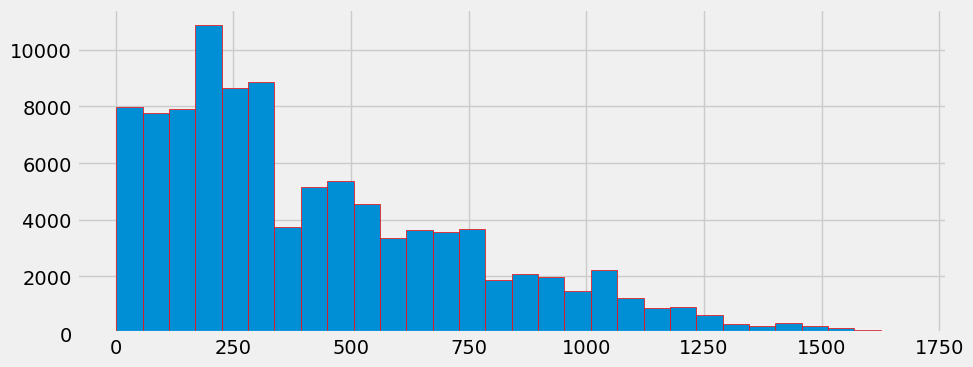

In [7]:
plt.hist(ratings['movie_id'],ec='r',bins=30)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

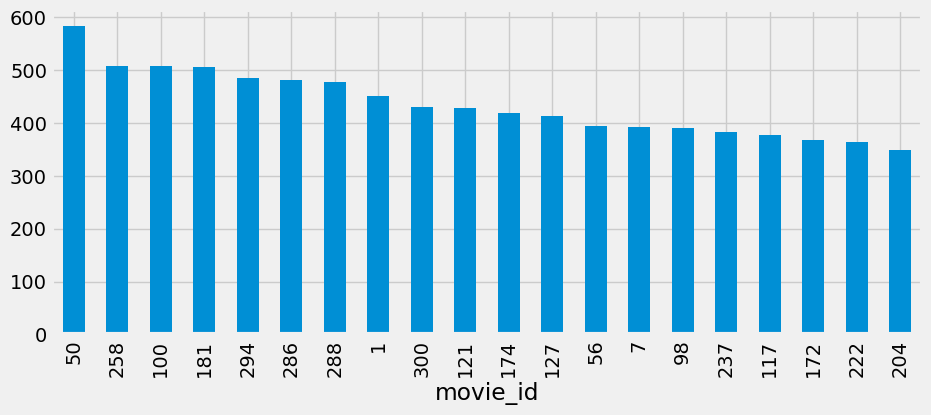

In [8]:
ratings['movie_id'].value_counts()[:20].plot(kind='bar')
plt.show

In [9]:
movie_property=ratings.groupby("movie_id").agg({'ratings':np.mean,'user_id':np.size})
movie_property.columns=["mean","size"]

C:\Users\DELL\AppData\Local\Temp\ipykernel_17012\3095670921.py:1: FutureWarning: The provided callable <function mean at 0x000002953E74FF60> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  movie_property=ratings.groupby("movie_id").agg({'ratings':np.mean,'user_id':np.size})


In [10]:
movie_property.head()

,mean,size
movie_id,,
1,3.878319,452
2,3.206107,131
3,3.033333,90
4,3.550239,209
5,3.302326,86


In [11]:
minimum=np.min(movie_property['size'])
maximum=np.max(movie_property['size'])
movie_property['popularity']=movie_property['size'].apply(lambda x: (x-minimum)/(maximum - minimum))

In [12]:
movie_property.head()

,mean,size,popularity
movie_id,,,
1,3.878319,452,0.773585
2,3.206107,131,0.222985
3,3.033333,90,0.152659
4,3.550239,209,0.356775
5,3.302326,86,0.145798


In [13]:
title=[]
l="""movie id | movie title | release date | video release date |
              IMDb URL | unknown | Action | Adventure | Animation |
              Children's | Comedy | Crime | Documentary | Drama | Fantasy |
              Film-Noir | Horror | Musical | Mystery | Romance | Sci-Fi |
              Thriller | War | Western """.split("|")
for t in l:
    title.append(t.strip())
print(title)
    

['movie id', 'movie title', 'release date', 'video release date', 'IMDb URL', 'unknown', 'Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


In [14]:
movie_df=pd.read_csv("u.item",encoding='latin',sep="|",names=title)

In [15]:
movie_df.head()

,movie id,movie title,release date,video release date,IMDb URL,unknown,Action,Adventure,Animation,Children's,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [16]:
movie_name = movie_df['movie title']

In [17]:
movie_name.index=movie_df['movie id']

In [18]:
movie_name[50]

'Star Wars (1977)'

In [19]:
movie_property.head()

,mean,size,popularity
movie_id,,,
1,3.878319,452,0.773585
2,3.206107,131,0.222985
3,3.033333,90,0.152659
4,3.550239,209,0.356775
5,3.302326,86,0.145798


In [20]:
movie_df.head()

,movie id,movie title,release date,video release date,IMDb URL,unknown,Action,Adventure,Animation,Children's,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [21]:
movie_df.index = movie_df['movie id']

In [22]:
movie_df=movie_df[['Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']]

In [23]:
all_properties=movie_property.join(movie_df)

In [37]:
movie_df.columns

Index(['Action', 'Adventure', 'Animation', 'Children's', 'Comedy', 'Crime',
       'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical',
       'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'],
      dtype='object')

In [39]:
all_properties.columns

Index(['mean', 'size', 'popularity', 'Action', 'Adventure', 'Animation',
       'Children's', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy',
       'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi',
       'Thriller', 'War', 'Western'],
      dtype='object')

In [24]:
from scipy.spatial.distance import cosine

In [25]:
movie_df.head()

,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
movie id,,,,,,,,,,,,,,,,,,
1,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
4,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0


In [46]:
def calculateDistance(id1,id2):
    pop_dis=abs(all_properties.loc[id1,'popularity']-all_properties.loc[id2,'popularity'])
    genre_dis=cosine(all_properties.loc[id1,'Action':'Western'],all_properties.loc[id2,'Action':'Western'])
    total_distance=pop_dis+genre_dis
    return total_distance

In [40]:
# def calculateDistance(id1,id2):
#     print("**In CalculateDistance before calculating popular Distance")
#     pop_dis = abs(all_properties.loc[id1,'popularity']-all_properties.loc[id2,'popularity'])
#     print("**In CalculateDistance before calculating genre Distance")
#     genre_dis = cosine(all_properties.loc[id1,'Action':'Western'],all_properties.loc[id2,'Action':'Western'])
#     print("**In CalculateDistance before calculating Total Distance")
#     total_distance = pop_dis+genre_dis
#     return total_distance

In [27]:
from operator import itemgetter

In [28]:
l=[(1,0.33),(2,0.44),(3,0.23),(4,0.55)]
l.sort(reverse=True)
print(l)

l.sort(key=itemgetter(1))
print(l)

[(4, 0.55), (3, 0.23), (2, 0.44), (1, 0.33)]
[(3, 0.23), (1, 0.33), (2, 0.44), (4, 0.55)]


In [29]:
f=itemgetter(8)

In [48]:
def getNeighbours(movie_id,k=5):
    distance = [(mid,calculateDistance(movie_id,mid)) for mid in all_properties.index if mid !=movie_id]
    distance.sort(key=itemgetter(1))
    distance = distance[:k]
    return [mid for mid,dis in distance]

In [31]:
all_properties.loc[50,'popularity']

np.float64(1.0)

In [32]:
all_properties.head()

,mean,size,popularity,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
movie_id,,,,,,,,,,,,,,,,,,,,,
1,3.878319,452,0.773585,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3.206107,131,0.222985,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,3.033333,90,0.152659,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,3.550239,209,0.356775,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
5,3.302326,86,0.145798,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


In [33]:
def similar_movie(movie_id, k=5):
    ids = getNeighbours(movie_id,k)
    print(f"So {k} Nearest Neighbours of {movie_name[movie_id]}")
    print("Rating\t\tName")
    for mid in ids:
        name = movie_name[mid]
        ratings = all_properties.loc[mid,'mean']
        print(f"{ratings}\t{name}")

In [34]:
all_properties.loc[1,'Action':'Western']

Action         0.0
Adventure      0.0
Animation      1.0
Children's     1.0
Comedy         1.0
Crime          0.0
Documentary    0.0
Drama          0.0
Fantasy        0.0
Film-Noir      0.0
Horror         0.0
Musical        0.0
Mystery        0.0
Romance        0.0
Sci-Fi         0.0
Thriller       0.0
War            0.0
Western        0.0
Name: 1, dtype: float64

In [49]:
similar_movie(50,10)

So 10 Nearest Neighbours of Star Wars (1977)
Rating		Name
4.007889546351085	Return of the Jedi (1983)
4.206521739130435	Empire Strikes Back, The (1980)
3.438228438228438	Independence Day (ID4) (1996)
3.66027397260274	Star Trek: First Contact (1996)
4.252380952380952	Raiders of the Lost Ark (1981)
3.2322274881516586	Starship Troopers (1997)
4.172839506172839	Princess Bride, The (1987)
3.7203065134099615	Jurassic Park (1993)
3.930513595166163	Indiana Jones and the Last Crusade (1989)
3.693121693121693	Rock, The (1996)
